In [1]:
import os
import numpy as np
import json
import re
import matplotlib.pyplot as plt

In [2]:
with open('Data/test_data.json', 'r', encoding='utf-8') as f:
    full_test_data = json.load(f)

In [13]:
test_data_aug = []
for item in full_test_data:
    bail_type = "Applicant applied for " + item['bail_type'] + ". "
    age = "The age of the applicant/s is/are " + str(item['ages']) + ". " if item['age_available'] else "Age not available. "
    health = "The health condition of the applicant is " + item['health_condition'] + " " if item['health_condition'] is not None else "none. "
    past = "Past criminal records for the applicant "+ ("exist." if item['past_criminal_record_exists'] else "do not exist.") + " "
    statutes = "The relevant statutes are: " + ", ".join(item['statutes']) + ". "
    custody = "The applicant is in custody for " + str(item['days_in_custody']) + " days. " if item['days_in_custody'] is not None else ""
    case_details = item['case_details'] + " " if item['case_details'] is not None else ""
    outcome = "The outcome of the case is " + item['outcome'] + "."
    reasoning = item['reasoning'] if item['reasoning'] is not None else ""
    statutes_info = " ".join(item['statute_details']) + " " if item['statute_details'] is not None else ""

    user_input = bail_type + age + health + past + statutes + custody + case_details + outcome
    test_data_aug.append({
        "CNR": item['CNR'],
        "case_details": user_input,
        "statutes": item['statutes'],
        "statutes_info": statutes_info,
        "outcome": item['outcome'],
        "reasoning": reasoning
    })

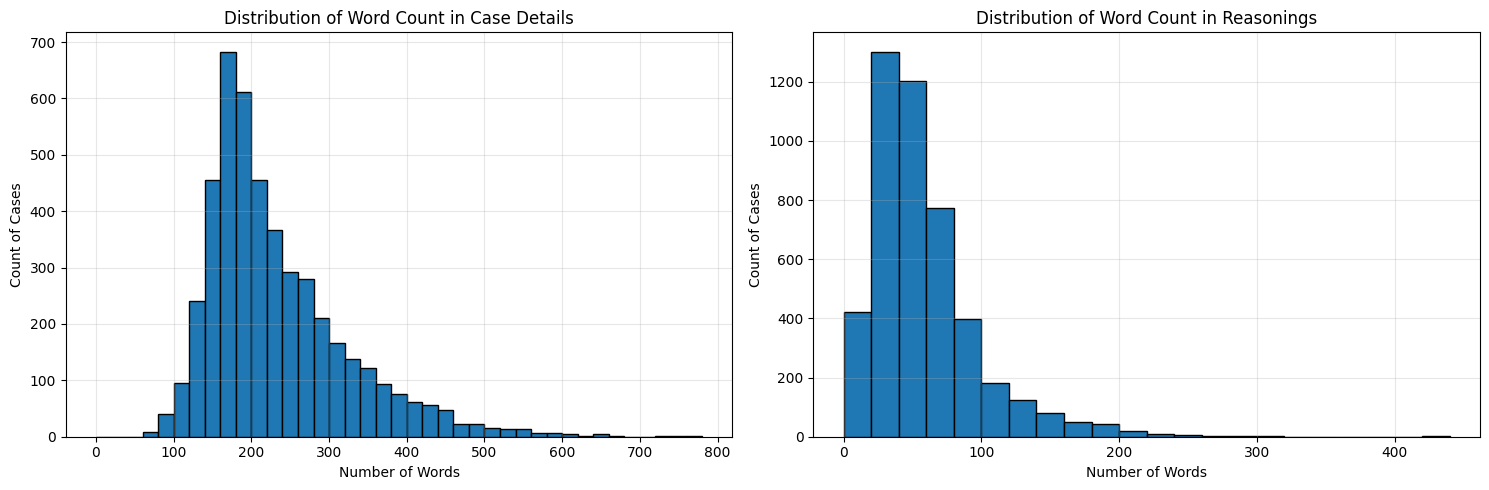

In [14]:
case_details = [item['case_details'] for item in test_data_aug]
reasonings = [item['reasoning'] for item in test_data_aug]
bin_size = 20

# Count words in case_details
case_details_word_counts = [len(detail.split()) for detail in case_details]
reasoning_word_counts = [len(reasoning.split()) for reasoning in reasonings]

# Create histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram for case_details
ax1.hist(case_details_word_counts, bins=range(0, max(case_details_word_counts) + bin_size, bin_size), edgecolor='black')
ax1.set_xlabel('Number of Words')
ax1.set_ylabel('Count of Cases')
ax1.set_title('Distribution of Word Count in Case Details')
ax1.grid(True, alpha=0.3)

# Histogram for reasonings
ax2.hist(reasoning_word_counts, bins=range(0, max(reasoning_word_counts) + bin_size, bin_size), edgecolor='black')
ax2.set_xlabel('Number of Words')
ax2.set_ylabel('Count of Cases')
ax2.set_title('Distribution of Word Count in Reasonings')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [15]:
lb_case_details = 300
lb_reasoning = 100
filtered_cases = [
    item for item in test_data_aug 
    if len(item['case_details'].split()) >= lb_case_details 
    and len(item['reasoning'].split()) >= lb_reasoning
]

count_filtered = len(filtered_cases)
print(f"Number of cases with at least {lb_case_details} words in case_details AND at least {lb_reasoning} words in reasoning: {count_filtered}")

Number of cases with at least 300 words in case_details AND at least 100 words in reasoning: 179


In [16]:
filtered_cases[0]

{'CNR': 'KLHC010042122018',
 'case_details': 'Applicant applied for anticipatory-bail. The age of the applicant/s is/are [37]. The health condition of the applicant is none. Past criminal records for the applicant do not exist. The relevant statutes are: 449 IPC, 302 IPC, 392 IPC. The applicant is in custody for 177 days. The accused is charged with the murder of a 47-year-old housewife inside her house, suspected to be a murder for gain as valuables were stolen. The accused allegedly trespassed into her house, attempted to sexually abuse her, attacked her with a broken ceremonial lamp and a stick, and smothered her causing her death. The accused is also alleged to have taken away gold ornaments, cash, a mobile phone, and the weapons used for the commission of the offence.\nArguments supporting the bail application are The investigation having been completed, there is no justification in denying him bail. The incident was in 2015, and the present investigating officer was in charge for

In [8]:
with open('./Data/test_data_for_reasoning_inference.json', 'w') as f:
    json.dump(filtered_cases, f, indent=4)

In [17]:
filtered_cases_2 = []
for item in filtered_cases:
    case_details = item['case_details']
    # remove the line "The outcome of the case is bail ..." from case_details
    case_details = re.sub(r'The outcome of the case is bail .*?\.', '', case_details)
    item['case_details'] = case_details.strip()
    filtered_cases_2.append(item)
    

In [18]:
filtered_cases_2[0]

{'CNR': 'KLHC010042122018',
 'case_details': 'Applicant applied for anticipatory-bail. The age of the applicant/s is/are [37]. The health condition of the applicant is none. Past criminal records for the applicant do not exist. The relevant statutes are: 449 IPC, 302 IPC, 392 IPC. The applicant is in custody for 177 days. The accused is charged with the murder of a 47-year-old housewife inside her house, suspected to be a murder for gain as valuables were stolen. The accused allegedly trespassed into her house, attempted to sexually abuse her, attacked her with a broken ceremonial lamp and a stick, and smothered her causing her death. The accused is also alleged to have taken away gold ornaments, cash, a mobile phone, and the weapons used for the commission of the offence.\nArguments supporting the bail application are The investigation having been completed, there is no justification in denying him bail. The incident was in 2015, and the present investigating officer was in charge for

In [19]:
with open('./Data/test_data_for_baseline_reasoning_inference.json', 'w') as f:
    json.dump(filtered_cases_2, f, indent=2)